# Explore here

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/workspaces/machine-learning-proyecto-arboles-decision/data/raw/diabetes (2).csv")

print("Forma del dataset:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)
print("\nNulos declarados (NaN) por columna:")
print(df.isnull().sum())
print("\nResumen estadístico:")
df.describe()

Forma del dataset: (768, 9)

Tipos de datos:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Nulos declarados (NaN) por columna:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Resumen estadístico:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [3]:
cols_sospechosas = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

zeros_resumen = pd.DataFrame({
    "n_ceros": (df[cols_sospechosas] == 0).sum(),
    "pct_ceros": (df[cols_sospechosas] == 0).mean() * 100
})

zeros_resumen

,n_ceros,pct_ceros
Glucose,5,0.651042
BloodPressure,35,4.557292
SkinThickness,227,29.557292
Insulin,374,48.697917
BMI,11,1.432292


In [4]:
from sklearn.model_selection import train_test_split

cols_sospechosas = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# Indicadores de faltante (no usan Outcome, seguros de crear antes del split)
df["SkinThickness_missing"] = (df["SkinThickness"] == 0).astype(int)
df["Insulin_missing"] = (df["Insulin"] == 0).astype(int)

# Reemplazar ceros por NaN en las columnas sospechosas
df[cols_sospechosas] = df[cols_sospechosas].replace(0, np.nan)

# Split ANTES de imputar
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("\nNaN en train:\n", X_train[cols_sospechosas].isnull().sum())

Train: (614, 10) Test: (154, 10)

NaN en train:
 Glucose            4
BloodPressure     23
SkinThickness    175
Insulin          290
BMI                9
dtype: int64


In [5]:
# Calcular medianas SOLO con train
medianas_train = X_train[cols_sospechosas].median()
print("Medianas calculadas en train:\n", medianas_train)

# Aplicar la misma imputación a train y test
X_train[cols_sospechosas] = X_train[cols_sospechosas].fillna(medianas_train)
X_test[cols_sospechosas] = X_test[cols_sospechosas].fillna(medianas_train)

# Verificación: no debería quedar ningún NaN en ninguno de los dos
print("\nNaN restantes en train:", X_train.isnull().sum().sum())
print("NaN restantes en test:", X_test.isnull().sum().sum())

Medianas calculadas en train:
 Glucose          117.0
BloodPressure     72.0
SkinThickness     29.0
Insulin          125.0
BMI               32.4
dtype: float64

NaN restantes en train: 0
NaN restantes en test: 0


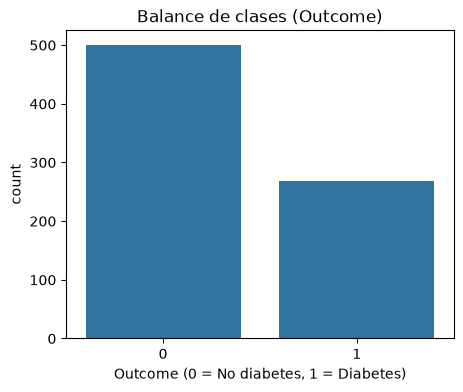

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x="Outcome", data=df, ax=ax)
ax.set_title("Balance de clases (Outcome)")
ax.set_xlabel("Outcome (0 = No diabetes, 1 = Diabetes)")
plt.show()

print(df["Outcome"].value_counts(normalize=True) * 100)

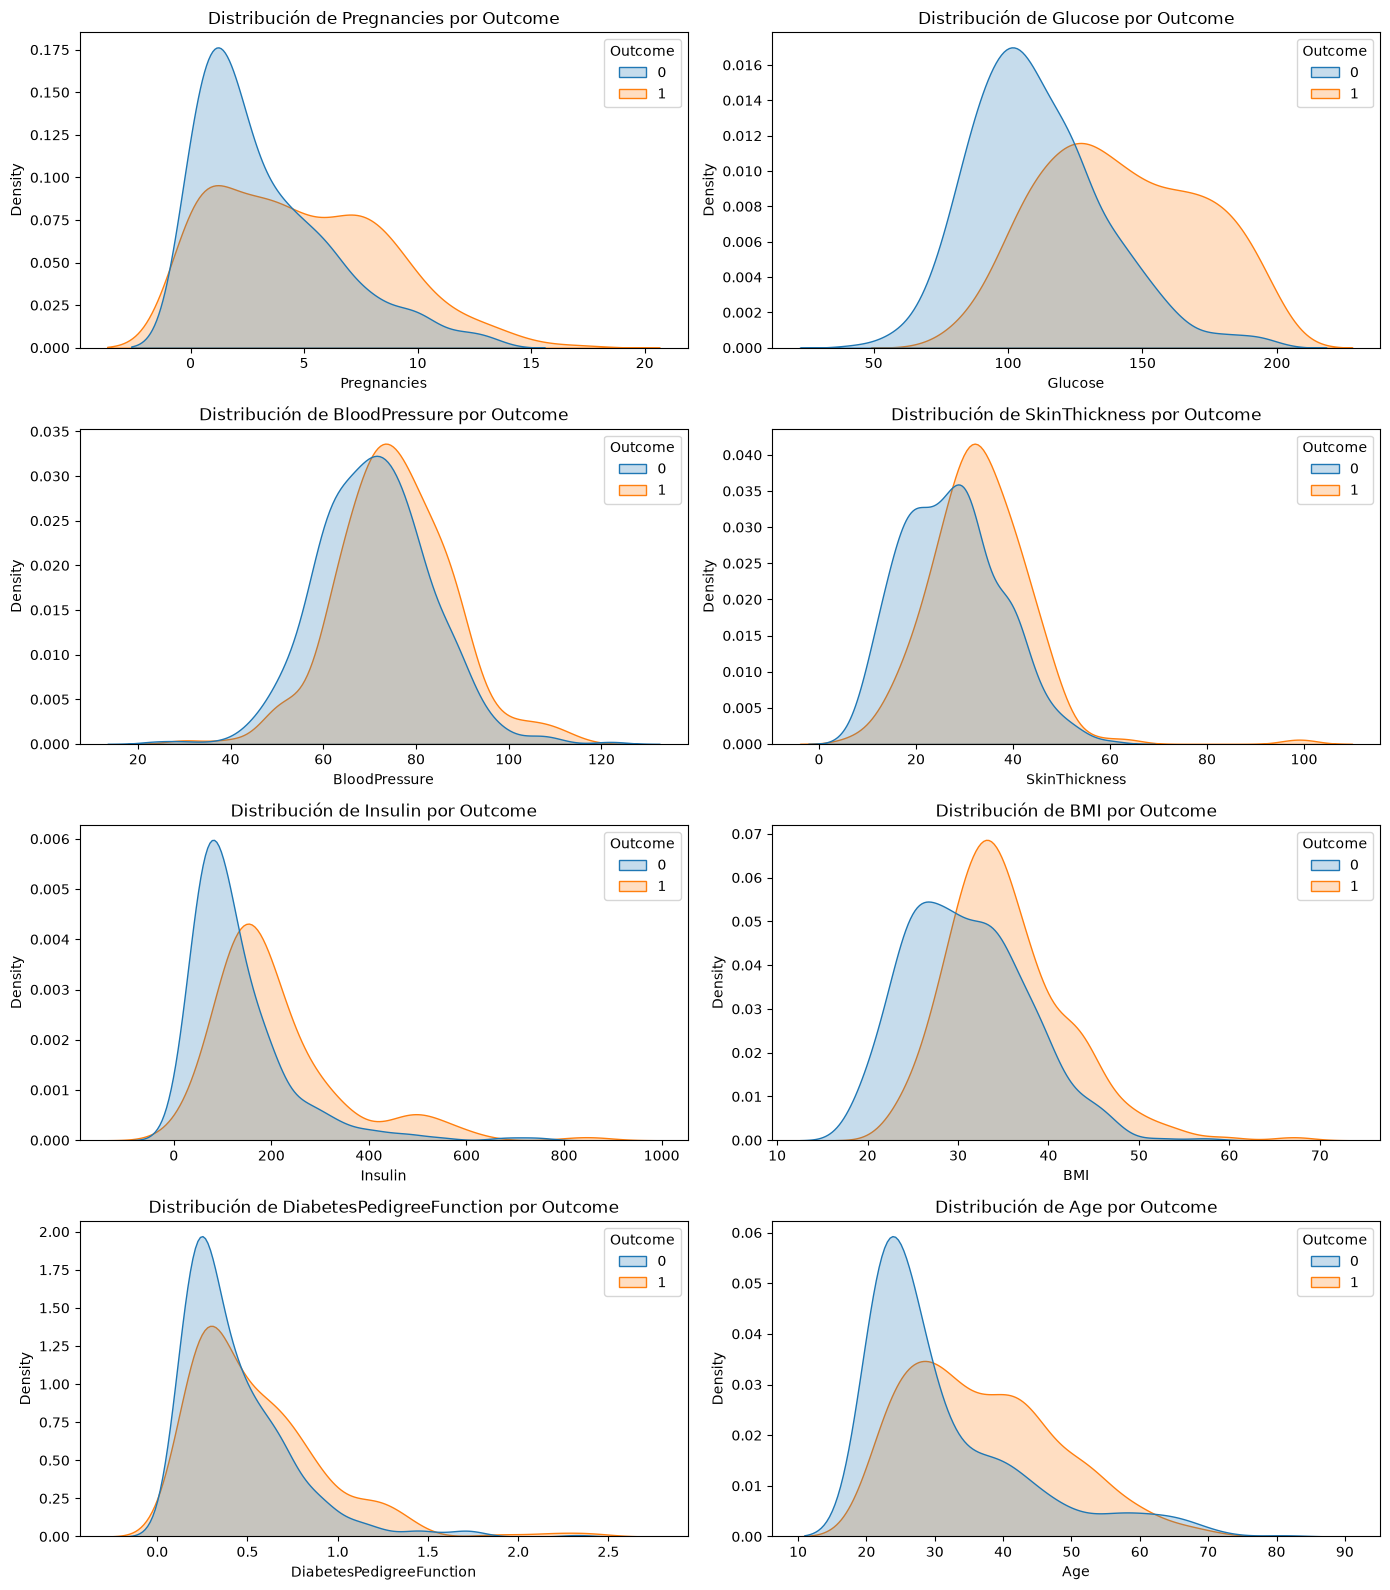

In [7]:
# Distribución de variables numéricas por Outcome
num_cols = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
            "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.kdeplot(data=df, x=col, hue="Outcome", fill=True, ax=axes[i], common_norm=False)
    axes[i].set_title(f"Distribución de {col} por Outcome")

plt.tight_layout()
plt.show()

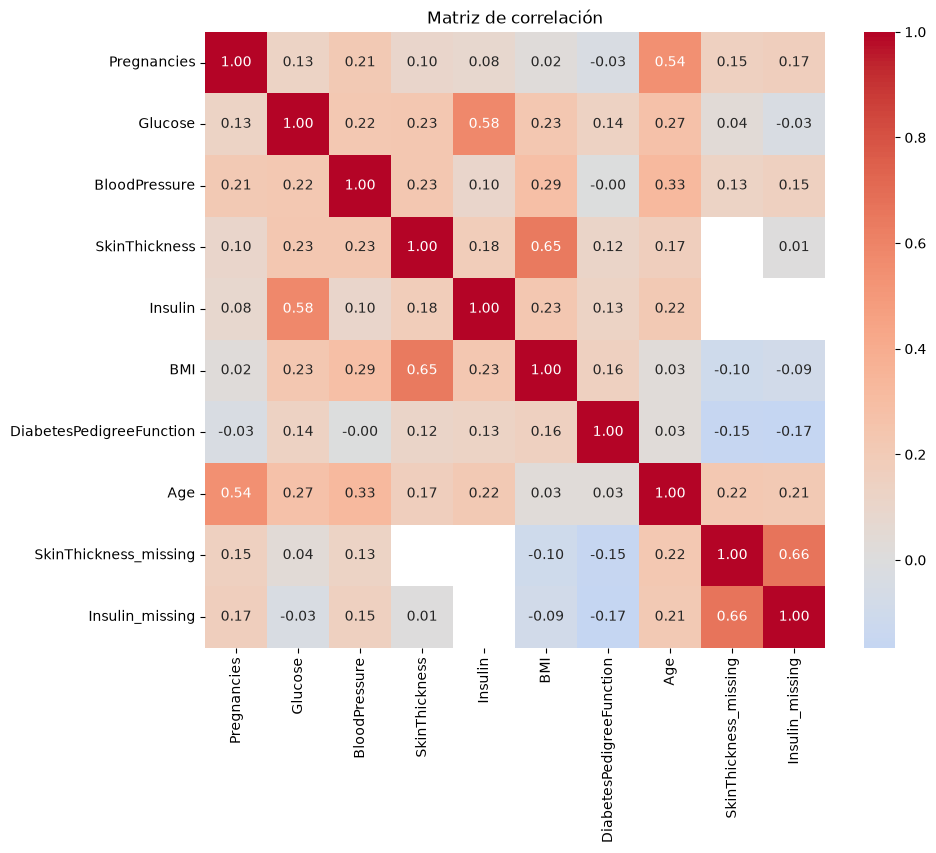

In [8]:
# Matriz de correlación
fig, ax = plt.subplots(figsize=(10, 8))
corr = df.drop(columns=["Outcome"]).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Matriz de correlación")
plt.show()

In [9]:
from sklearn.tree import DecisionTreeClassifier

tree_baseline = DecisionTreeClassifier(random_state=42)
tree_baseline.fit(X_train, y_train)

print("Profundidad del árbol:", tree_baseline.get_depth())
print("Número de hojas:", tree_baseline.get_n_leaves())

Profundidad del árbol: 14
Número de hojas: 111


=== TRAIN ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       1.00      1.00      1.00       214

    accuracy                           1.00       614
   macro avg       1.00      1.00      1.00       614
weighted avg       1.00      1.00      1.00       614


=== TEST ===
              precision    recall  f1-score   support

           0       0.73      0.79      0.76       100
           1       0.54      0.46      0.50        54

    accuracy                           0.68       154
   macro avg       0.64      0.63      0.63       154
weighted avg       0.67      0.68      0.67       154

AUC en test: 0.6264814814814815


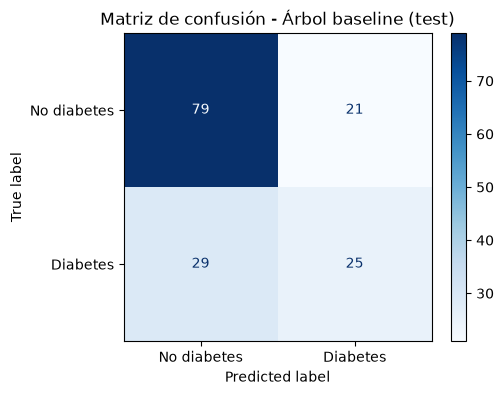

In [10]:
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Predicciones
y_train_pred = tree_baseline.predict(X_train)
y_test_pred = tree_baseline.predict(X_test)
y_test_proba = tree_baseline.predict_proba(X_test)[:, 1]

# Comparación train vs test
print("=== TRAIN ===")
print(classification_report(y_train, y_train_pred))
print("\n=== TEST ===")
print(classification_report(y_test, y_test_pred))

print("AUC en test:", roc_auc_score(y_test, y_test_proba))

# Matriz de confusión (test)
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(cm, display_labels=["No diabetes", "Diabetes"]).plot(ax=ax, cmap="Blues")
ax.set_title("Matriz de confusión - Árbol baseline (test)")
plt.show()

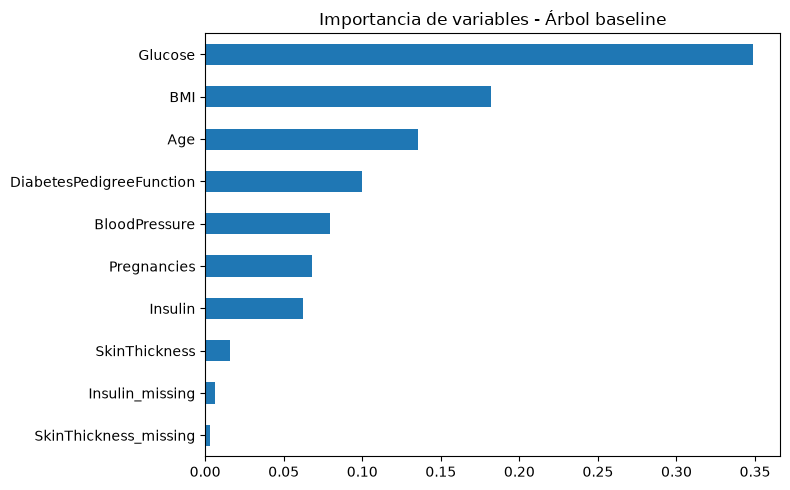

Glucose                     0.348454
BMI                         0.181715
Age                         0.135523
DiabetesPedigreeFunction    0.099610
BloodPressure               0.079622
Pregnancies                 0.067722
Insulin                     0.062171
SkinThickness               0.015923
Insulin_missing             0.005962
SkinThickness_missing       0.003300
dtype: float64

In [11]:
importancias = pd.Series(tree_baseline.feature_importances_, index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
importancias.plot(kind="barh", ax=ax)
ax.set_title("Importancia de variables - Árbol baseline")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

importancias

In [12]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 4, 5, 6, 7],
    "min_samples_leaf": [5, 10, 20],
    "class_weight": [None, "balanced"]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1",  # priorizamos F1 de la clase positiva por el desbalance
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid_search.best_params_)
print("Mejor F1 (CV):", grid_search.best_score_)

tree_tuned = grid_search.best_estimator_
print("\nProfundidad del árbol podado:", tree_tuned.get_depth())
print("Número de hojas:", tree_tuned.get_n_leaves())

Mejores hiperparámetros: {'class_weight': 'balanced', 'max_depth': 3, 'min_samples_leaf': 5}
Mejor F1 (CV): 0.6655542876651913

Profundidad del árbol podado: 3
Número de hojas: 8


=== TRAIN (podado) ===
              precision    recall  f1-score   support

           0       0.91      0.64      0.75       400
           1       0.57      0.89      0.69       214

    accuracy                           0.73       614
   macro avg       0.74      0.77      0.72       614
weighted avg       0.79      0.73      0.73       614


=== TEST (podado) ===
              precision    recall  f1-score   support

           0       0.88      0.59      0.71       100
           1       0.53      0.85      0.65        54

    accuracy                           0.68       154
   macro avg       0.70      0.72      0.68       154
weighted avg       0.76      0.68      0.69       154

AUC en test (podado): 0.7835185185185185


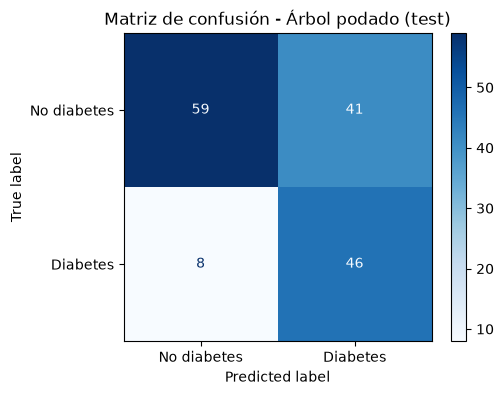

In [13]:
# Predicciones con el árbol podado
y_train_pred_tuned = tree_tuned.predict(X_train)
y_test_pred_tuned = tree_tuned.predict(X_test)
y_test_proba_tuned = tree_tuned.predict_proba(X_test)[:, 1]

print("=== TRAIN (podado) ===")
print(classification_report(y_train, y_train_pred_tuned))
print("\n=== TEST (podado) ===")
print(classification_report(y_test, y_test_pred_tuned))

print("AUC en test (podado):", roc_auc_score(y_test, y_test_proba_tuned))

# Matriz de confusión
fig, ax = plt.subplots(figsize=(5, 4))
cm_tuned = confusion_matrix(y_test, y_test_pred_tuned)
ConfusionMatrixDisplay(cm_tuned, display_labels=["No diabetes", "Diabetes"]).plot(ax=ax, cmap="Blues")
ax.set_title("Matriz de confusión - Árbol podado (test)")
plt.show()

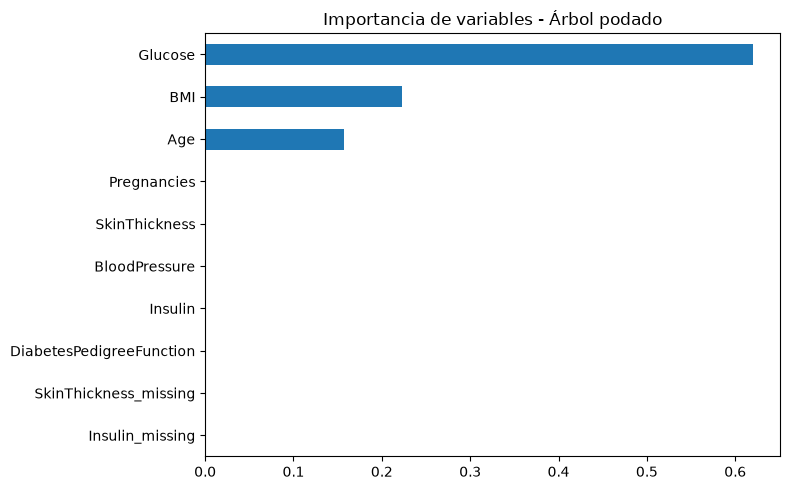

Glucose                     0.619688
BMI                         0.222701
Age                         0.157611
Pregnancies                 0.000000
SkinThickness               0.000000
BloodPressure               0.000000
Insulin                     0.000000
DiabetesPedigreeFunction    0.000000
SkinThickness_missing       0.000000
Insulin_missing             0.000000
dtype: float64

In [14]:
# Importancia de variables (árbol podado)
importancias_tuned = pd.Series(tree_tuned.feature_importances_, index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
importancias_tuned.plot(kind="barh", ax=ax)
ax.set_title("Importancia de variables - Árbol podado")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

importancias_tuned

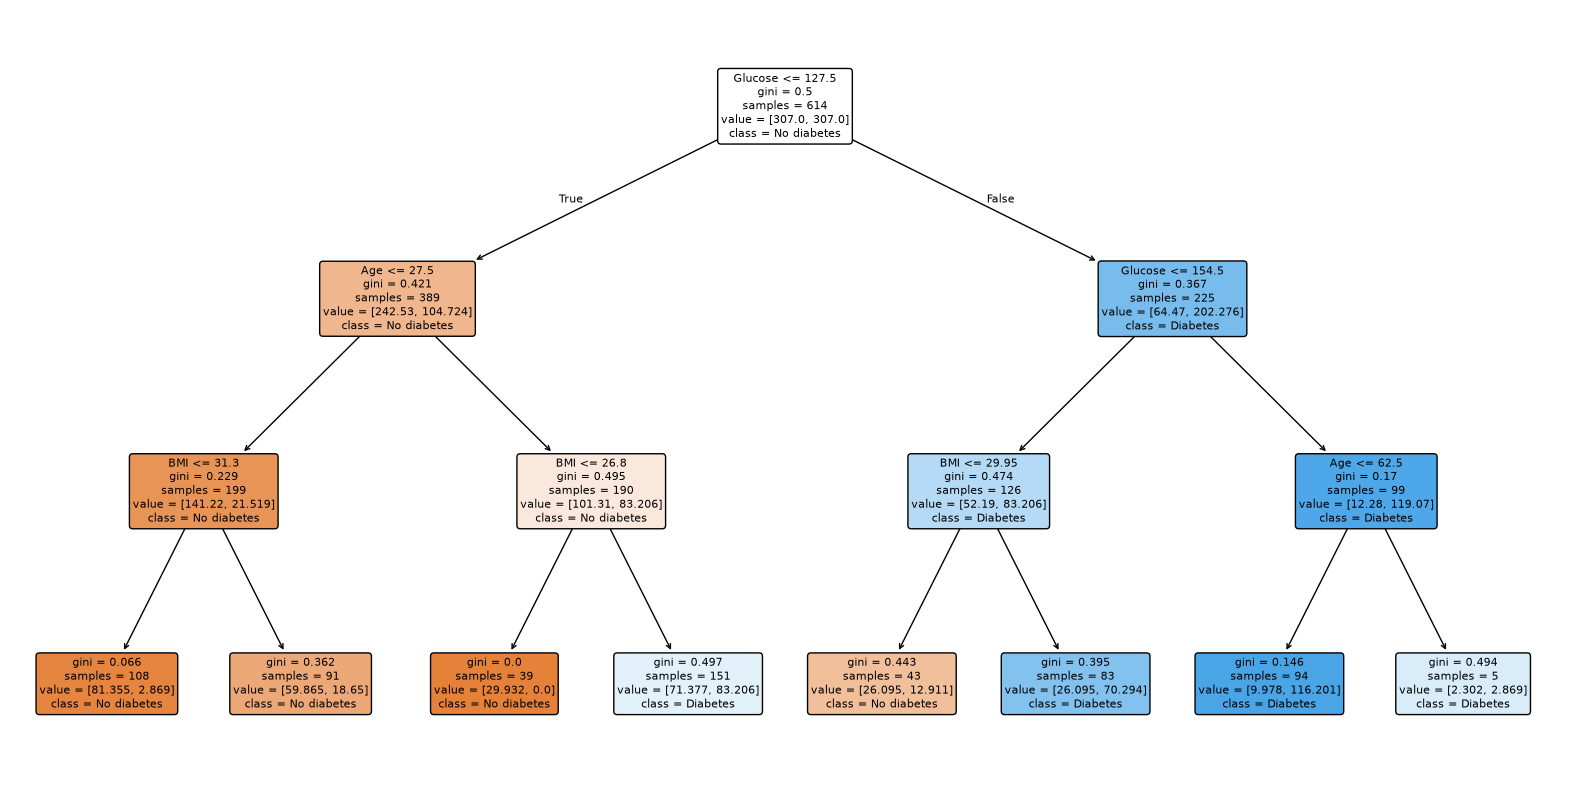

In [15]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    tree_tuned,
    feature_names=X_train.columns,
    class_names=["No diabetes", "Diabetes"],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax
)
plt.show()

**Conclusiones**
- Hiperparámetros: max_depth=3, min_samples_leaf=5, class_weight='balanced' (vía GridSearchCV, cv=5, scoring=F1).
- Test: Accuracy 0.68, F1 (Diabetes) 0.65, Recall (Diabetes) 0.85, AUC 0.78.
- Variables más importantes: Glucose (62%), BMI (22%), Age (16%).
- El modelo prioriza recall sobre precision, adecuado para un contexto de screening médico 
  donde es preferible un falso positivo (estudios adicionales) a un falso negativo (diabetes no detectada).
  
Cabe recalcar que las variables más importantes en la predicción del modelo son:

1- Glucose

2- BMI

3- Age